In [32]:
# Cargo las librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Cargo librerías para el preprocesamiento de datos
from sklearn.model_selection import train_test_split # Dividir los datos en conjuntos de entrenamiento y prueba
from sklearn.preprocessing import StandardScaler # Estandarización de características
from sklearn.impute import SimpleImputer # Manejo de valores faltantes
# Si es necesario, cargo librerías de datasets de ejemplo
from sklearn.datasets import load_iris # Dataset de ejemplo (Iris)

# Si es necesario, cargo librerías para la ingeniería de características (Opcional)
from sklearn.preprocessing import OneHotEncoder # Codificación de variables categóricas
# Cargo librerías para la construcción de modelos
from sklearn.linear_model import LinearRegression # Algoritmo que usaremos en el estudio. Regresión lineal
from sklearn.linear_model import Ridge, Lasso # Regresión Ridge y Lasso (Regularización)
# Cargo librerías para la evaluación de modelos
from sklearn import metrics # Métricas de evaluación

### Cargar u obtener el Dataset

Paso 1. Definir el problema y recopilar los datos

Definición del problema: Predecir el precio de las viviendas de Boston, dadas unas características.

In [33]:
def leer_boston():
    ulr = "https://lib.stat.cmu.edu/datasets/boston" # URL del dataset de Boston
    df = pd.read_csv(ulr, sep="\s+", skiprows=22, header=None) # Leo el dataset, uso separador de espacios, salto las primeras 22 filas y no uso encabezados
    # El dataset tiene una estructura especial, por lo que se necesita un procesamiento adicional
    # El conjunto de datos tiene 14 columnas, las primeras 13 son características y la última es el valor objetivo (precio de la vivienda)
    # Los datos están organizados en bloques de 2 filas por muestra
    data = np.hstack([df.values[::2, :], df.values[1::2, :2]]) # Combino las filas pares e impares. Está cogiendo todas las columnas de las filas pares y las dos primeras columnas de las filas impares
    target = df.values[1::2, 2] # El valor objetivo está en la segunda fila de cada bloque
    return {'data': data, 'target': target, "feature_names": ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]} # Retorno un diccionario con los datos y el objetivo

In [34]:
data = leer_boston()
df = pd.DataFrame(data['data'], columns=data['feature_names']) # Características
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [35]:
df['MEDV'] = data['target'] # Agrego la columna del valor objetivo al DataFrame
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


Cargarlo desde el fichero housing.csv

In [36]:
df2 = pd.read_csv("../datasets/housing.csv", header=None, sep=r"\s+", names=data['feature_names'] + ['MEDV']) # Cargo el dataset de viviendas de Boston desde un archivo local
df2.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


Paso 2. Preprocesar los datos

- Manejo de datos faltantes
- Manejo de datos categóricos

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [38]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [39]:
np.round(df.corr(), 2) # muestra la matriz de correlación redondeada a 2 decimales

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.00,-0.20,0.41,-0.06,0.42,-0.22,0.35,-0.38,0.63,0.58,0.29,-0.39,0.46,-0.39
ZN,-0.20,1.00,-0.53,-0.04,-0.52,0.31,-0.57,0.66,-0.31,-0.31,-0.39,0.18,-0.41,0.36
INDUS,0.41,-0.53,1.00,0.06,0.76,-0.39,0.64,-0.71,0.60,0.72,0.38,-0.36,0.60,-0.48
CHAS,-0.06,-0.04,0.06,1.00,0.09,0.09,0.09,-0.10,-0.01,-0.04,-0.12,0.05,-0.05,0.18
NOX,0.42,-0.52,0.76,0.09,1.00,-0.30,0.73,-0.77,0.61,0.67,0.19,-0.38,0.59,-0.43
RM,-0.22,0.31,-0.39,0.09,-0.30,1.00,-0.24,0.21,-0.21,-0.29,-0.36,0.13,-0.61,0.70
AGE,0.35,-0.57,0.64,0.09,0.73,-0.24,1.00,-0.75,0.46,0.51,0.26,-0.27,0.60,-0.38
DIS,-0.38,0.66,-0.71,-0.10,-0.77,0.21,-0.75,1.00,-0.49,-0.53,-0.23,0.29,-0.50,0.25
RAD,0.63,-0.31,0.60,-0.01,0.61,-0.21,0.46,-0.49,1.00,0.91,0.46,-0.44,0.49,-0.38
TAX,0.58,-0.31,0.72,-0.04,0.67,-0.29,0.51,-0.53,0.91,1.00,0.46,-0.44,0.54,-0.47


<Axes: >

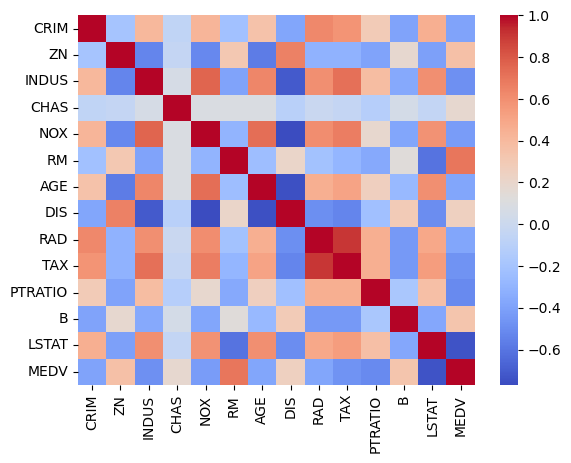

In [40]:
sns.heatmap(np.round(df.corr(), 2), cmap="coolwarm") # Mapa de calor de la matriz de correlación

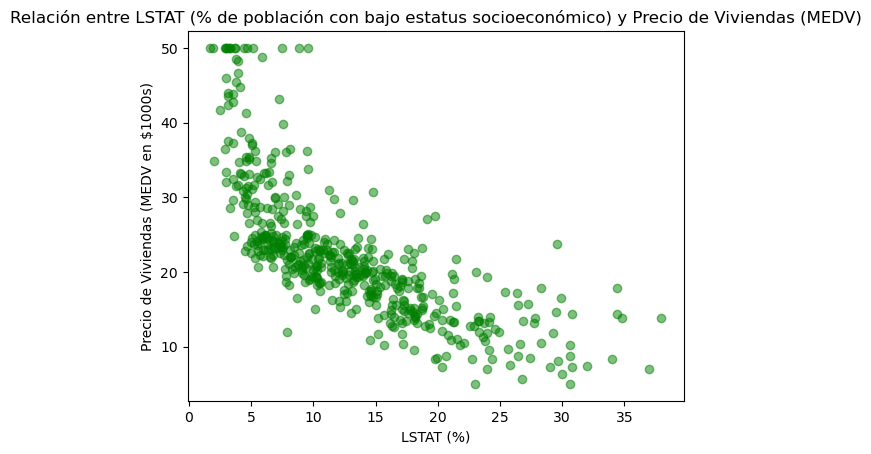

In [41]:
# LSTAT tiene una correlación negativa fuerte con MEDV (-0.74)
plt.scatter(df['LSTAT'], df['MEDV'], color='green', alpha=0.5)
plt.title('Relación entre LSTAT (% de población con bajo estatus socioeconómico) y Precio de Viviendas (MEDV)')
plt.xlabel('LSTAT (%)')
plt.ylabel('Precio de Viviendas (MEDV en $1000s)')
plt.show()

Paso 3. Elección del modelo a utilizar

In [42]:
model = LinearRegression() # Creo una instancia del modelo de regresión lineal
ridge_model = Ridge(alpha=1.0)  # alpha es el parámetro de regularización λ
laso_model = Lasso(alpha=0.1)  # alpha es el parámetro de regularización λ


Paso 4. División entre variables independientes y la variable dependiente

In [43]:
X = df.iloc[:, :-1] # Características (todas las columnas excepto la última). Variables independientes
y = df.iloc[:, -1] # Valor objetivo (última columna). Variable dependiente

Paso 5. Dividir el dataset en conjunto de entrenamiento y test

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Divido los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba). El valor de random_state asegura reproducibilidad

Paso 6. Entrenar el modelo

In [45]:
model.fit(X_train, y_train) # Entreno el modelo con los datos de entrenamiento
# Standarizo las características
scaler = StandardScaler() # Creo una instancia del escalador
# Ridge
X_train_ridge = scaler.fit_transform(X_train) # Ajusto y transformo los datos de entrenamiento con Ridge
X_test_ridge = scaler.transform(X_test) # Transformo los datos de prueba con Ridge
ridge_model.fit(X_train_ridge, y_train) # Entreno el modelo Ridge con los datos estandarizados
# Lasso
X_train_lasso = scaler.fit_transform(X_train) # Ajusto y transformo los datos de entrenamiento con Lasso
X_test_lasso = scaler.transform(X_test) # Transformo los datos de prueba con Lasso
laso_model.fit(X_train_lasso, y_train) # Entreno el modelo Lasso con los datos estandarizados

Lasso(alpha=0.1)

Paso 7. Predicción de datos

In [46]:
pred = model.predict(X_test) # Hago predicciones con el conjunto de prueba. Obtengo los valores predichos por el modelo (un MEDV para cada muestra en X_test)
# Ridge
pred_ridge = ridge_model.predict(X_test_ridge) # Hago predicciones con el conjunto de prueba estandarizado para Ridge
# Lasso
pred_lasso = laso_model.predict(X_test_lasso) # Hago predicciones con el conjunto de prueba estandarizado para Lasso

Paso 8. Cálculo de métricas

In [47]:
print(f"Regresión Lineal:")
print("Evaluación del modelo de Regresión Lineal con el conjunto de entrenamiento:")
print("MAE (Mean Absolute Error):", metrics.mean_absolute_error(y_train, model.predict(X_train))) # Error absoluto medio
print("MSE (Mean Squared Error):", metrics.mean_squared_error(y_train, model.predict(X_train))) # Error cuadrático medio
print("RMSE (Root Mean Squared Error):", np.sqrt(metrics.mean_squared_error(y_train, model.predict(X_train)))) # Raíz del error cuadrático medio
print("R² (R-squared):", metrics.r2_score(y_train, model.predict(X_train))) # Coeficiente de determinación R² indica la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes.
print("MAPE (Mean Absolute Percentage Error):", metrics.mean_absolute_percentage_error(y_train, model.predict(X_train))) # Error porcentual absoluto medio
print("Evaluación del modelo de Regresión Lineal con el conjunto de prueba:")
print("MAE (Mean Absolute Error):", metrics.mean_absolute_error(y_test, pred)) # Error absoluto medio
print("MSE (Mean Squared Error):", metrics.mean_squared_error(y_test, pred)) # Error cuadrático medio
print("RMSE (Root Mean Squared Error):", np.sqrt(metrics.mean_squared_error(y_test, pred))) # Raíz del error cuadrático medio
print("R² (R-squared):", metrics.r2_score(y_test, pred)) # Coeficiente de determinación R² indica la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes.
print("MAPE (Mean Absolute Percentage Error):", metrics.mean_absolute_percentage_error(y_test, pred)) # Error porcentual absoluto medio

Regresión Lineal:
Evaluación del modelo de Regresión Lineal con el conjunto de entrenamiento:
MAE (Mean Absolute Error): 3.3147716267832266
MSE (Mean Squared Error): 21.641412753226312
RMSE (Root Mean Squared Error): 4.6520331848801675
R² (R-squared): 0.7508856358979673
MAPE (Mean Absolute Percentage Error): 0.16574914349533953
Evaluación del modelo de Regresión Lineal con el conjunto de prueba:
MAE (Mean Absolute Error): 3.189091965887852
MSE (Mean Squared Error): 24.291119474973602
RMSE (Root Mean Squared Error): 4.928602182665345
R² (R-squared): 0.6687594935356309
MAPE (Mean Absolute Percentage Error): 0.16866394539378737


In [48]:
print(f"Regresión Lineal con Ridge:")
print("Evaluación del modelo de Regresión Lineal con el conjunto de entrenamiento:")
print("MAE (Mean Absolute Error):", metrics.mean_absolute_error(y_train, ridge_model.predict(X_train_ridge))) # Error absoluto medio
print("MSE (Mean Squared Error):", metrics.mean_squared_error(y_train, ridge_model.predict(X_train_ridge))) # Error cuadrático medio
print("RMSE (Root Mean Squared Error):", np.sqrt(metrics.mean_squared_error(y_train, ridge_model.predict(X_train_ridge)))) # Raíz del error cuadrático medio
print("R² (R-squared):", metrics.r2_score(y_train, ridge_model.predict(X_train_ridge))) # Coeficiente de determinación R² indica la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes.
print("MAPE (Mean Absolute Percentage Error):", metrics.mean_absolute_percentage_error(y_train, ridge_model.predict(X_train_ridge))) # Error porcentual absoluto medio
print("Evaluación del modelo de Regresión Lineal con el conjunto de prueba:")
print("MAE (Mean Absolute Error):", metrics.mean_absolute_error(y_test, pred_ridge)) # Error absoluto medio
print("MSE (Mean Squared Error):", metrics.mean_squared_error(y_test, pred_ridge)) # Error cuadrático medio
print("RMSE (Root Mean Squared Error):", np.sqrt(metrics.mean_squared_error(y_test, pred_ridge))) # Raíz del error cuadrático medio
print("R² (R-squared):", metrics.r2_score(y_test, pred_ridge)) # Coeficiente de determinación R² indica la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes.
print("MAPE (Mean Absolute Percentage Error):", metrics.mean_absolute_percentage_error(y_test, pred_ridge)) # Error porcentual absoluto medio

Regresión Lineal con Ridge:
Evaluación del modelo de Regresión Lineal con el conjunto de entrenamiento:
MAE (Mean Absolute Error): 3.3087078437180253
MSE (Mean Squared Error): 21.642750577373906
RMSE (Root Mean Squared Error): 4.652176971845966
R² (R-squared): 0.7508702362003778
MAPE (Mean Absolute Percentage Error): 0.1653791504791975
Evaluación del modelo de Regresión Lineal con el conjunto de prueba:
MAE (Mean Absolute Error): 3.185723807244597
MSE (Mean Squared Error): 24.31290383049161
RMSE (Root Mean Squared Error): 4.930811680696355
R² (R-squared): 0.6684624359643558
MAPE (Mean Absolute Percentage Error): 0.1685467621959076


In [49]:
print(f"Regresión Lineal Lasso:")
print("Evaluación del modelo de Regresión Lineal con el conjunto de entrenamiento:")
print("MAE (Mean Absolute Error):", metrics.mean_absolute_error(y_train, laso_model.predict(X_train_lasso))) # Error absoluto medio
print("MSE (Mean Squared Error):", metrics.mean_squared_error(y_train, laso_model.predict(X_train_lasso))) # Error cuadrático medio
print("RMSE (Root Mean Squared Error):", np.sqrt(metrics.mean_squared_error(y_train, laso_model.predict(X_train_lasso)))) # Raíz del error cuadrático medio
print("R² (R-squared):", metrics.r2_score(y_train, laso_model.predict(X_train_lasso))) # Coeficiente de determinación R² indica la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes.
print("MAPE (Mean Absolute Percentage Error):", metrics.mean_absolute_percentage_error(y_train, laso_model.predict(X_train_lasso))) # Error porcentual absoluto medio
print("Evaluación del modelo de Regresión Lineal con el conjunto de prueba:")
print("MAE (Mean Absolute Error):", metrics.mean_absolute_error(y_test, pred_lasso)) # Error absoluto medio
print("MSE (Mean Squared Error):", metrics.mean_squared_error(y_test, pred_lasso)) # Error cuadrático medio
print("RMSE (Root Mean Squared Error):", np.sqrt(metrics.mean_squared_error(y_test, pred_lasso))) # Raíz del error cuadrático medio
print("R² (R-squared):", metrics.r2_score(y_test, pred_lasso)) # Coeficiente de determinación R² indica la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes.
print("MAPE (Mean Absolute Percentage Error):", metrics.mean_absolute_percentage_error(y_test, pred_lasso)) # Error porcentual absoluto medio

Regresión Lineal Lasso:
Evaluación del modelo de Regresión Lineal con el conjunto de entrenamiento:
MAE (Mean Absolute Error): 3.2657656638148946
MSE (Mean Squared Error): 22.149496782370278
RMSE (Root Mean Squared Error): 4.706325188761427
R² (R-squared): 0.7450370791852485
MAPE (Mean Absolute Percentage Error): 0.1624438664346246
Evaluación del modelo de Regresión Lineal con el conjunto de prueba:
MAE (Mean Absolute Error): 3.2418034658794648
MSE (Mean Squared Error): 25.656739367167685
RMSE (Root Mean Squared Error): 5.06524820390548
R² (R-squared): 0.6501375183238985
MAPE (Mean Absolute Percentage Error): 0.17286381645271612


Extra: cálculo de los coeficientes del modelo y el intercepto

y = a + b1*x1 + b2*x2 ... bn*xn # a es el intercepto, bi son los coeficientes que aporta cada variable, xi son sus características

In [50]:
print(f"Intercepto: {model.intercept_}") # Intercepto del modelo con regresión lineal
print(f"Coeficientes: {model.coef_}") # Coeficientes del modelo con regresión lineal
print(f"Intercepto Ridge: {ridge_model.intercept_}") # Intercepto del modelo con regresión lineal Ridge
print(f"Coeficientes Ridge: {ridge_model.coef_}") # Coeficientes del modelo con regresión lineal Ridge
print(f"Intercepto Lasso: {laso_model.intercept_}") # Intercepto del modelo con regresión lineal Lasso
print(f"Coeficientes Lasso: {laso_model.coef_}") # Coeficientes del modelo con regresión lineal Lasso

Intercepto: 30.246750993923598
Coeficientes: [-1.13055924e-01  3.01104641e-02  4.03807204e-02  2.78443820e+00
 -1.72026334e+01  4.43883520e+00 -6.29636221e-03 -1.44786537e+00
  2.62429736e-01 -1.06467863e-02 -9.15456240e-01  1.23513347e-02
 -5.08571424e-01]
Intercepto Ridge: 22.796534653465343
Coeficientes Ridge: [-0.99218679  0.6777488   0.2522143   0.72248078 -1.99083465  3.15157218
 -0.17726162 -3.04502895  2.17324941 -1.69555879 -2.02783351  1.127197
 -3.59897667]
Intercepto Lasso: 22.796534653465343
Coeficientes Lasso: [-0.71836455  0.25962714 -0.          0.69822096 -1.56814243  3.27150693
 -0.         -2.28444944  0.67193802 -0.3566537  -1.89333519  1.03136581
 -3.60941047]


In [51]:
parametros = pd.DataFrame({'Característica': X.columns, 'Coeficiente': model.coef_}) # Creo un DataFrame con las características y sus coeficientes
parametros = parametros.sort_values(by='Coeficiente', ascending=False) # Ordeno el DataFrame por coeficiente de mayor a menor
parametros

,Característica,Coeficiente
5,RM,4.438835
3,CHAS,2.784438
8,RAD,0.262430
2,INDUS,0.040381
1,ZN,0.030110
11,B,0.012351
6,AGE,-0.006296
9,TAX,-0.010647
0,CRIM,-0.113056
12,LSTAT,-0.508571


In [52]:
parametros_ridge = pd.DataFrame({'Característica': X.columns, 'Coeficiente': ridge_model.coef_}) # Creo un DataFrame con las características y sus coeficientes
parametros_ridge = parametros_ridge.sort_values(by='Coeficiente', ascending=False) # Ordeno el DataFrame por coeficiente de mayor a menor
parametros_ridge

,Característica,Coeficiente
5,RM,3.151572
8,RAD,2.173249
11,B,1.127197
3,CHAS,0.722481
1,ZN,0.677749
2,INDUS,0.252214
6,AGE,-0.177262
0,CRIM,-0.992187
9,TAX,-1.695559
4,NOX,-1.990835


y = VALOR_INTERCEPTO_RIDGE + 3.15*RM + 2.17*RAD ... -3.59*LSTAT

In [53]:
parametros_lasso = pd.DataFrame({'Característica': X.columns, 'Coeficiente': laso_model.coef_}) # Creo un DataFrame con las características y sus coeficientes
parametros_lasso = parametros_lasso.sort_values(by='Coeficiente', ascending=False) # Ordeno el DataFrame por coeficiente de mayor a menor
parametros_lasso

,Característica,Coeficiente
5,RM,3.271507
11,B,1.031366
3,CHAS,0.698221
8,RAD,0.671938
1,ZN,0.259627
2,INDUS,-0.000000
6,AGE,-0.000000
9,TAX,-0.356654
0,CRIM,-0.718365
4,NOX,-1.568142


### Consideraciones finales

#### Comparación general

- En términos de MSE, el modelo con el menor error cuadrático puede considerarse el mejor en términos de precisión en la predicción
- En términos de R2 (coeficiente de determinación), un valor alto indica que el modelo explica mejor la variabilidad de los datos
- Ridge y Lasso son útiles cuando se requiere tratamiento del sobreajuste (overfitting), especialmente con un gran número de características y con multicolinealidad
- En este caso, se debe elegir en función de un equilibrio entre la simplicidad (Lasso), la estabilidad del sobreajuste (Ridge) y la "precisión" (Regresión Lineal)